# Source A — Key Findings: Wikipedia Intro-Text County Embeddings

This notebook shows the most important, already-verified results from
`analysis-output/source-a-findings.md`. It loads existing computed
artifacts (`stats.json`, saved figures, cluster/similarity CSVs) rather
than re-running the full analysis pipeline, so numbers here match the
findings report exactly.

**Bottom line**: `BAAI/bge-m3` embeddings of county Wikipedia intros carry
a real but small geographic signal (Mantel r ≈ -0.24, p = 0.002). Neither
PCA nor K-means finds strong thematic structure beyond that weak
geographic effect, and embedding more article text does not help.
See `analysis-output/source-a-findings.md` for full detail, caveats, and
allowed/forbidden claim wording.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "analysis-output" else Path.cwd()
FIGURES_DIR = REPO_ROOT / "analysis-output" / "figures"

with open(REPO_ROOT / "analysis-output" / "stats.json") as f:
    stats = json.load(f)

stats

{'pc1_n_counties': 3144,
 'pc1_explained_variance_ratio': 0.03938401217011231,
 'clustering_n_counties': 2849,
 'silhouette_scores_by_k': {'2': 0.028369260700928055,
  '3': 0.02532290415106648,
  '4': 0.01768599180661845,
  '5': 0.018918288968133468,
  '6': 0.016448201360560306,
  '7': 0.018039222031232358,
  '8': 0.01700668381342948,
  '9': 0.02202552715809628,
  '10': 0.02157939559099141,
  '11': 0.024844797417565345,
  '12': 0.02468592381970887},
 'selected_k': 2,
 'selected_k_silhouette': 0.028369260700928055,
 'mantel_r': -0.2362260568502109,
 'mantel_p': 0.002,
 'mantel_n_permutations': 499,
 'mantel_seed': 42,
 'corpus_mean_pairwise_km': 1455.275524419369,
 'cluster_sizes': {'0': 1420, '1': 1429},
 'cluster_mean_intra_km': {'0': 1634.6707242522516, '1': 1242.512786674773}}

## 1. Dataset

3,144 U.S. counties (full coverage of every US county/county-equivalent,
after backfilling the 37 Virginia independent cities and 19 remaining
Census-Gazetteer-vs-Wikipedia-title mismatches), each with a 1,024-dim,
L2-normalized `bge-m3` embedding of its Wikipedia intro text. Metadata is
limited to FIPS code, county name, and lat/lon centroid — no economic
variables are joined in yet.

In [2]:
embeddings_df = pd.read_parquet(REPO_ROOT / "source_a_embeddings.parquet")
print(f"{len(embeddings_df):,} counties, embedding dim = {len(embeddings_df['embedding'].iloc[0])}")
embeddings_df[["county_name", "fips_code"]].head()

3,144 counties, embedding dim = 1024


,county_name,fips_code
0,"Autauga County, Alabama",01001
1,"Baldwin County, Alabama",01003
2,"Barbour County, Alabama",01005
3,"Bibb County, Alabama",01007
4,"Blount County, Alabama",01009


## 2. Finding: Geography ↔ Similarity Is Weak but Real (Mantel Test)

Nearby counties are very slightly more textually similar than far-apart
ones. This is statistically significant (permutation-tested, not a naive
pairwise p-value) but small in magnitude — geography is not a dominant
driver of these embeddings.

Mantel r = -0.2362
Mantel p = 0.0020  (499 permutations, seed=42)
n counties in this test = 2,849


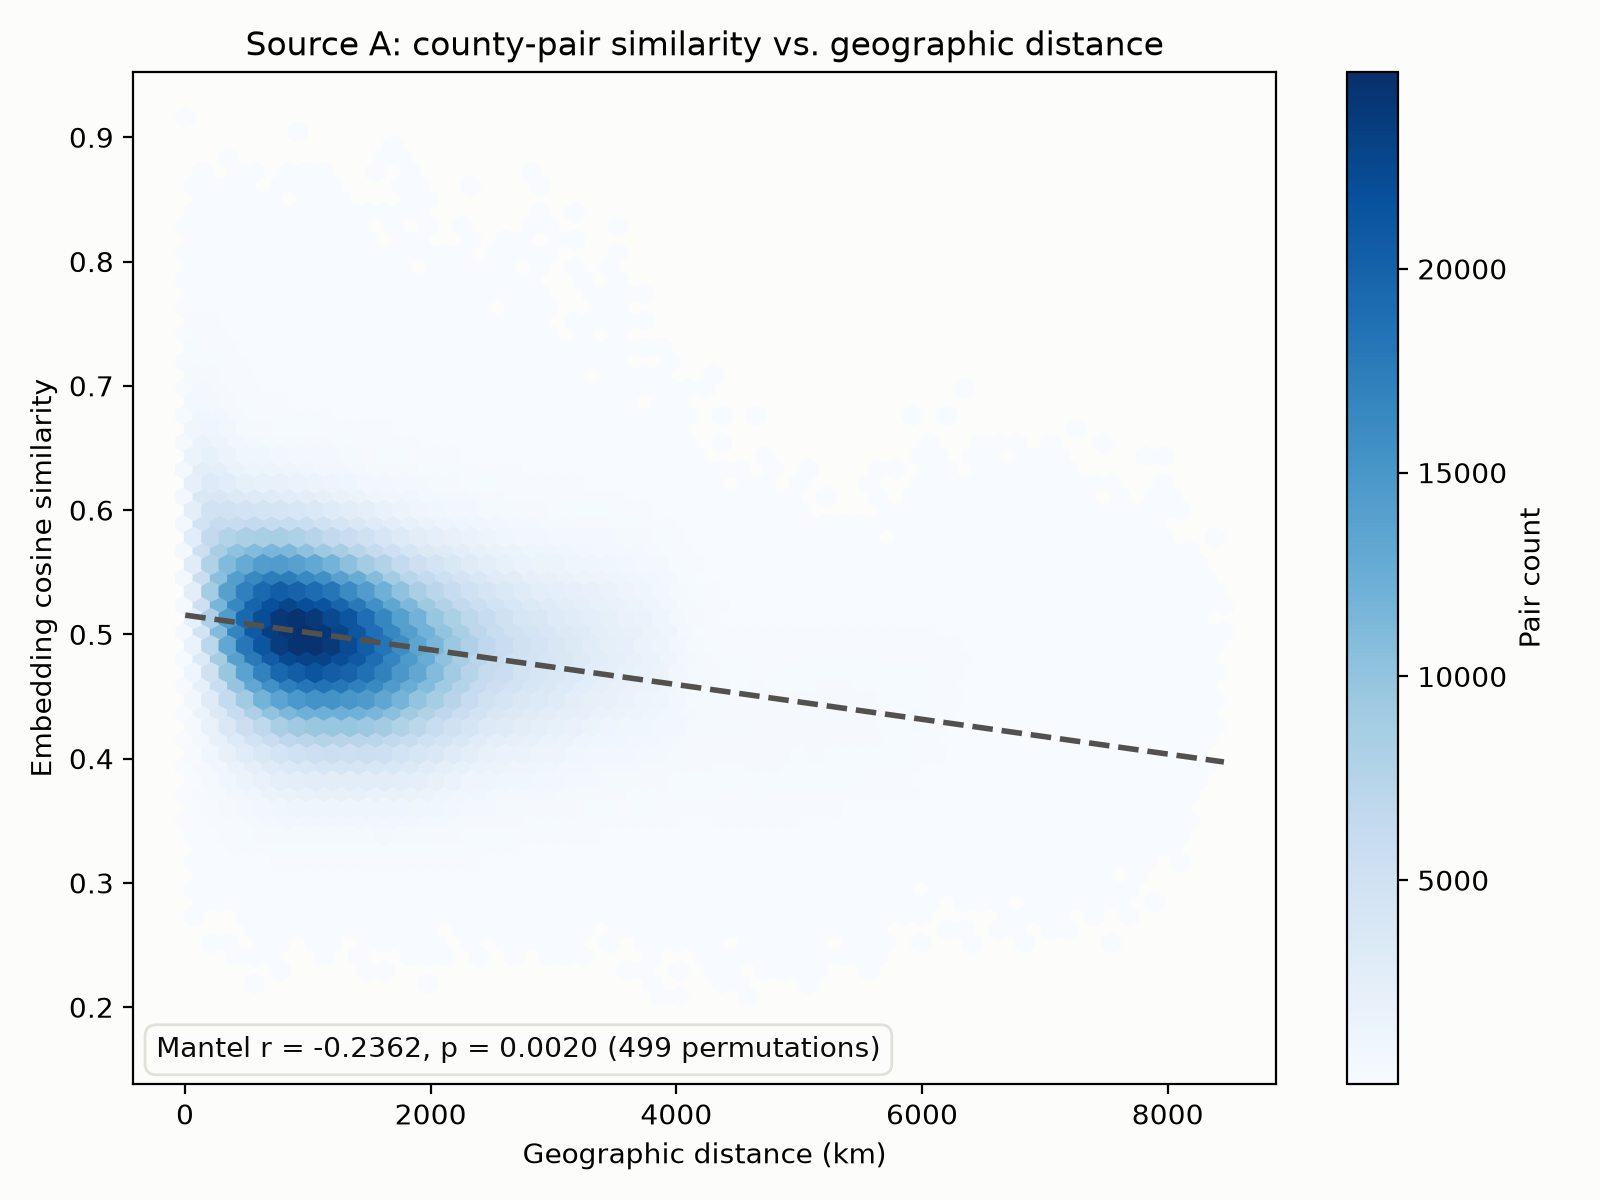

In [3]:
print(f"Mantel r = {stats['mantel_r']:.4f}")
print(f"Mantel p = {stats['mantel_p']:.4f}  ({stats['mantel_n_permutations']} permutations, seed={stats['mantel_seed']})")
print(f"n counties in this test = {stats['clustering_n_counties']:,}")

display(Image(filename=str(FIGURES_DIR / "figure-01-similarity-vs-distance.png")))

The shallow trend line (similarity drops only slightly across the full
distance range) confirms "weak," not "strong." A handful of far-apart
county pairs are still highly similar in text — consistent with geography
mattering only a little on average:

In [4]:
similarity_pairs = pd.read_csv(REPO_ROOT / "source_a_similarity_pairs.csv")
similarity_pairs.head()

,county_a,county_b,similarity,distance_km
0,"Madison County, Montana","Madison County, Virginia",0.875999,2866.347718
1,"Jefferson County, Georgia","Jefferson County, Idaho",0.865269,2844.515139
2,"Washington County, Idaho","Washington County, Wisconsin",0.856630,2279.288717
3,"Washington County, Kansas","Washington County, New York",0.847705,2000.492484
4,"Lincoln County, Washington","Lincoln County, West Virginia",0.842100,3107.211001


**Why these top 5 are similar despite being 2,000+ km apart** — two
surface-level mechanisms, neither reflecting real geographic or economic
kinship:

- **Shared eponym** (#1 Lincoln KS↔OR, #4 Franklin ME↔NE): both counties
  in a pair are named after the same historical figure (Abraham Lincoln,
  Benjamin Franklin), so their articles reuse the same "named for X"
  sentence almost verbatim.
- **Generic-boilerplate convergence** (#2, #3, #5, all involving
  Stutsman County, ND): short, minimally-elaborated articles with little
  distinguishing content sit close to the corpus's templated-boilerplate
  centroid, so they read as "similar" to any other equally generic
  article regardless of subject.

See `analysis-output/source-a-findings.md` §3.4 for the full per-pair
breakdown.

## 3. Finding: PCA Finds No Dominant or Thematic Structure

PC1 explains only ~3.9% of total embedding variance, and a manual read of
its highest/lowest-loading counties found generic formation/demographic
boilerplate on both ends — **no semantic label should be attached to
PC1**.

PC1 explained variance ratio = 0.0394
n counties = 3,144


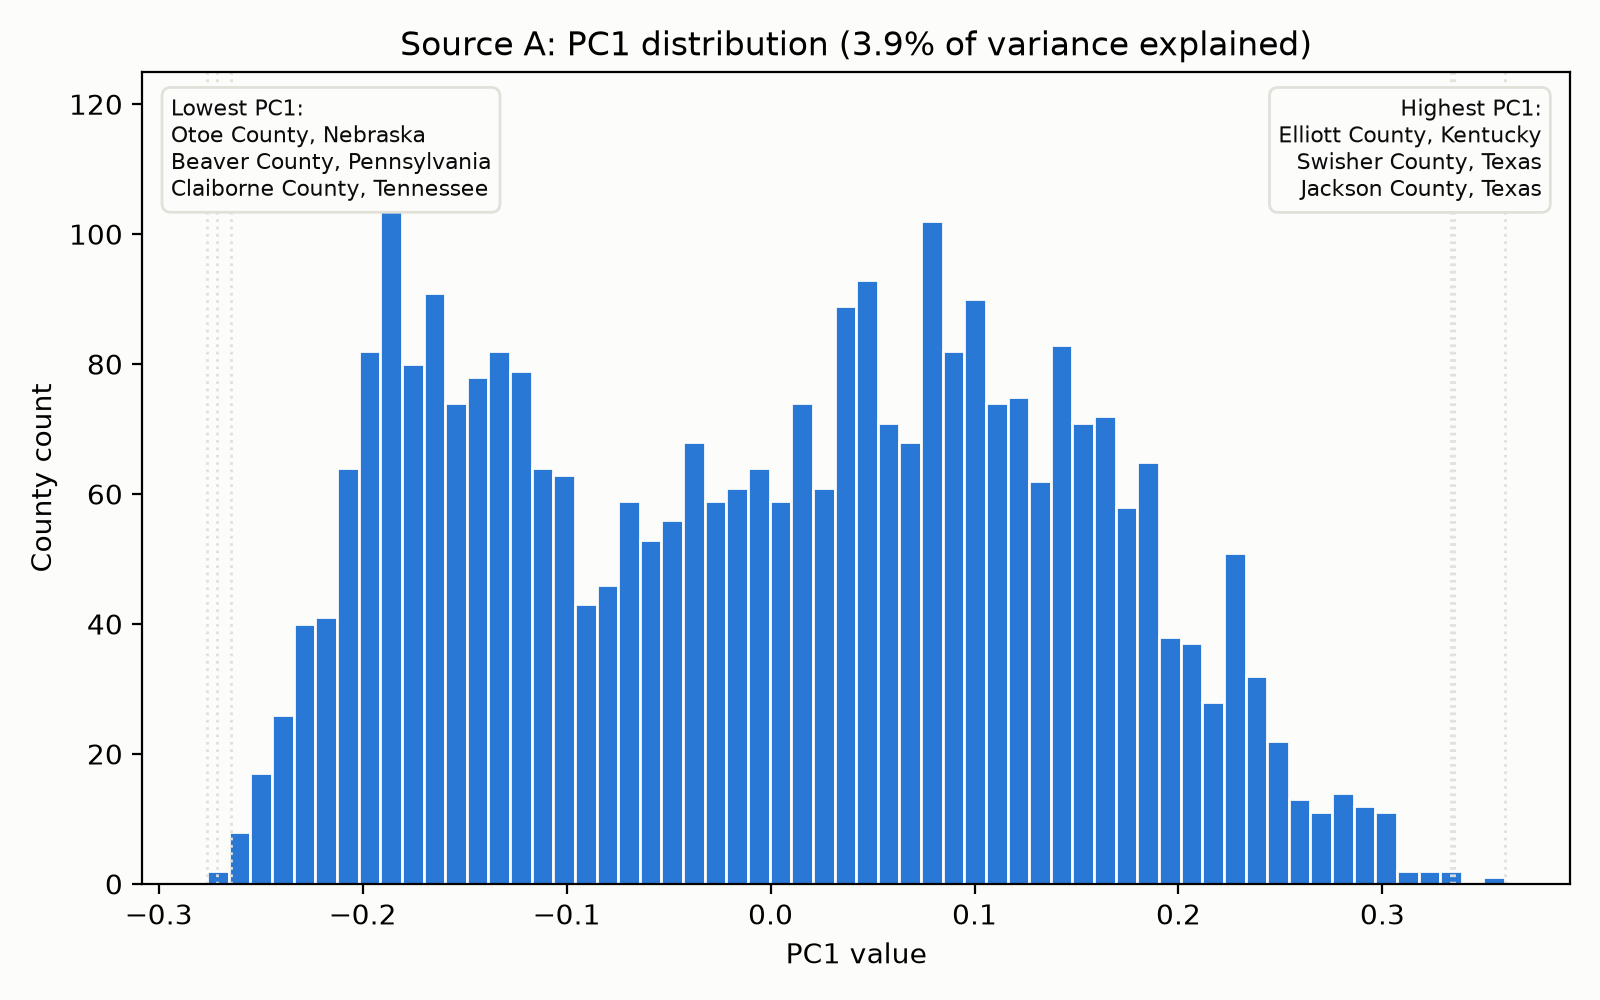

In [5]:
print(f"PC1 explained variance ratio = {stats['pc1_explained_variance_ratio']:.4f}")
print(f"n counties = {stats['pc1_n_counties']:,}")

display(Image(filename=str(FIGURES_DIR / "figure-02-pc1-distribution.png")))

## 4. Finding: K-means Clustering Is Weak, but Its k=2 Split Is Real and Stable

Silhouette scores are low at every k tried (max ≈0.028, well under the
~0.25 threshold usually associated with real cluster structure) — the
"best" clustering (k=2) is a weak fit, not a good one. Its two clusters
deviate from the corpus-wide mean pairwise distance in **opposite
directions** (one tighter, one looser) by similar magnitudes — not a
coherent regional split.

Selected k = 2 (silhouette = 0.0284)


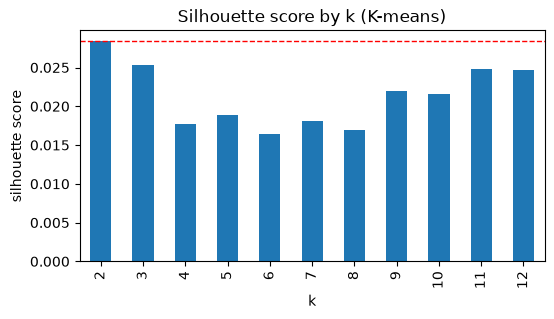

In [6]:
silhouette_by_k = pd.Series(stats["silhouette_scores_by_k"]).rename_axis("k").rename("silhouette")
silhouette_by_k.index = silhouette_by_k.index.astype(int)
silhouette_by_k = silhouette_by_k.sort_index()
ax = silhouette_by_k.plot(kind="bar", figsize=(6, 3), title="Silhouette score by k (K-means)")
ax.axhline(stats["selected_k_silhouette"], color="red", linestyle="--", linewidth=1)
ax.set_ylabel("silhouette score")
print(f"Selected k = {stats['selected_k']} (silhouette = {stats['selected_k_silhouette']:.4f})")

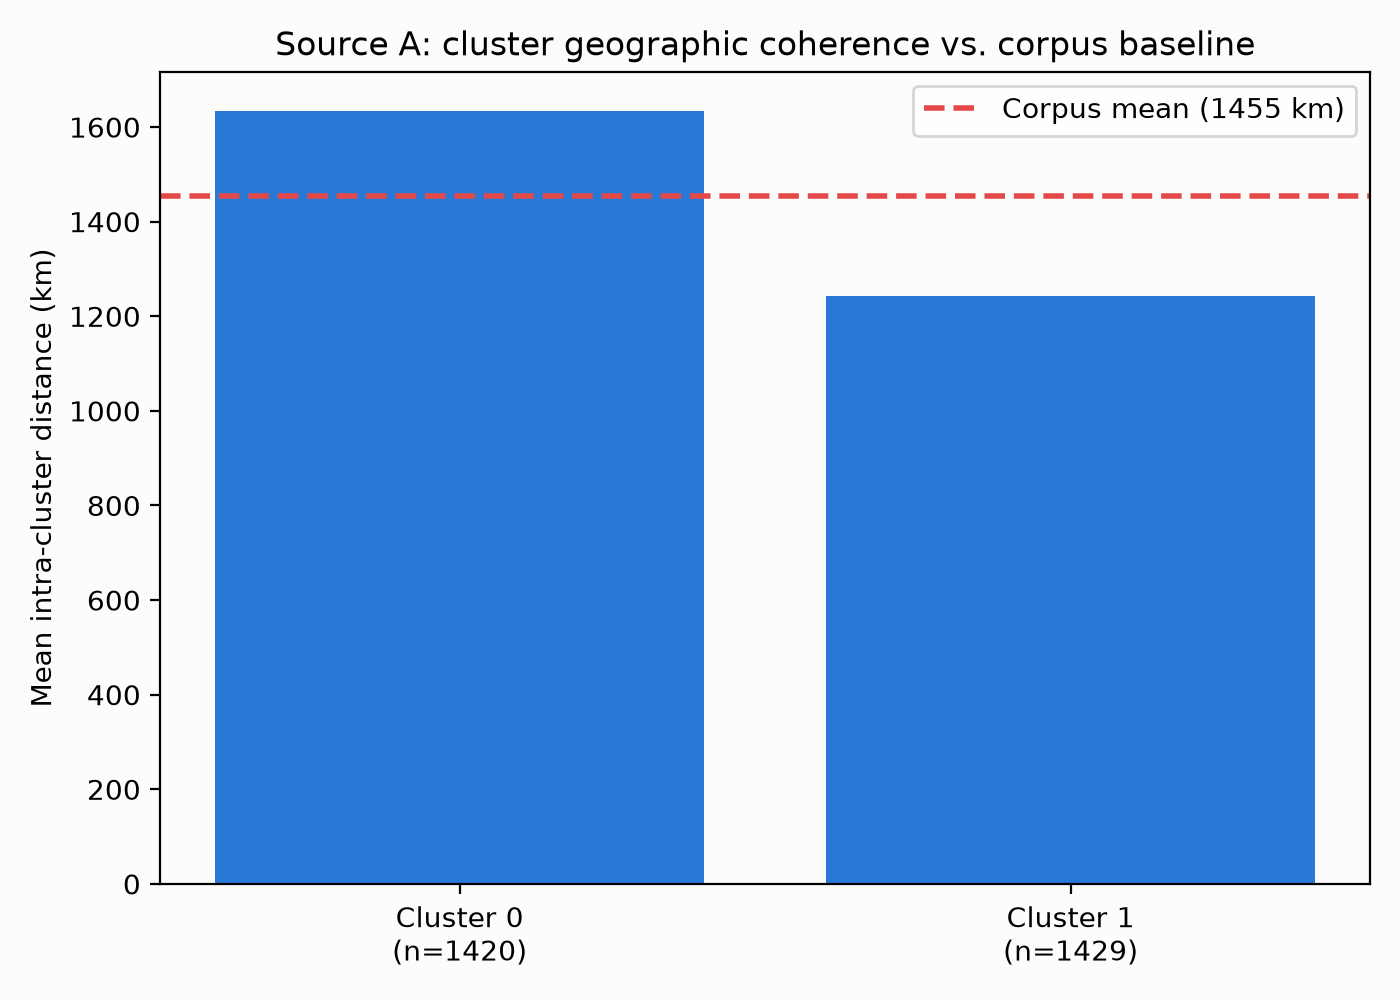

,cluster,cluster_size,mean_intra_cluster_km,corpus_mean_pairwise_km
0,0,1420,1634.670724,1455.275524
5,1,1429,1242.512787,1455.275524


In [7]:
display(Image(filename=str(FIGURES_DIR / "figure-03-cluster-coherence.png")))

cluster_summary = pd.read_csv(REPO_ROOT / "source_a_cluster_summary.csv")
cluster_summary.drop_duplicates(subset="cluster")[
    ["cluster", "cluster_size", "mean_intra_cluster_km", "corpus_mean_pairwise_km"]
]

Despite the weak silhouette, this k=2 split is **highly reproducible**
across random seeds (cross-seed stability check, `analyze_source_a_cluster_stability.py`)
and its ~12-15% geographic-coherence deviation from the corpus mean is
statistically real (permutation p ≤ 0.001, both directions) — small, but
not noise:

In [8]:
stability_summary = pd.DataFrame({
    "metric": [
        "Silhouette (mean across 5 seeds)",
        "Silhouette (std across 5 seeds)",
        "Pairwise ARI across 10 seed-pairs (mean)",
        "Pairwise ARI across 10 seed-pairs (range)",
        "Cluster-coherence permutation p-value (both clusters)",
    ],
    "value": ["0.0343", "0.0008", "0.9955", "0.9916 - 1.0000", "<= 0.001"],
})
stability_summary

,metric,value
0,Silhouette (mean across 5 seeds),0.0343
1,Silhouette (std across 5 seeds),0.0008
2,Pairwise ARI across 10 seed-pairs (mean),0.9955
3,Pairwise ARI across 10 seed-pairs (range),0.9916 - 1.0000
4,Cluster-coherence permutation p-value (both cl...,<= 0.001


**Caveat**: reproducible and statistically real does not mean well
separated — silhouette stays ≤0.029 throughout, so do not describe the
two clusters as "regions."

## 5. Negative Result: Embedding More Article Text Does Not Help

A prototype tested two variants — embedding 3 additional body sections, and
an Economy-only section — against the intro-only baseline on a fixed
40-county sample.

In [9]:
section_expansion = pd.DataFrame(
    {
        "Metric": [
            "Mean text length",
            "Pairwise similarity mean",
            "Pairwise similarity std",
            "Mantel r (geo <-> similarity)",
        ],
        "Intro-only": ["694 chars", "0.559", "0.068", "-0.272, p=0.004"],
        "Lead + 3 body sections": ["4,532 chars (6.5x)", "0.585", "0.054", "-0.372, p=0.002"],
        "Intro-only (same 10)": ["949 chars", "0.556", "0.069", "-0.287, p=0.016"],
        "Economy-only": ["697 chars", "0.509", "0.072", "-0.093, p=0.494 (n.s.)"],
    }
).set_index("Metric")
section_expansion

,Intro-only,Lead + 3 body sections,Intro-only (same 10),Economy-only
Metric,,,,
Mean text length,694 chars,"4,532 chars (6.5x)",949 chars,697 chars
Pairwise similarity mean,0.559,0.585,0.556,0.509
Pairwise similarity std,0.068,0.054,0.069,0.072
Mantel r (geo <-> similarity),"-0.272, p=0.004","-0.372, p=0.002","-0.287, p=0.016","-0.093, p=0.494 (n.s.)"


Adding 6.5x more text (body sections) made counties **more** alike, not
less — consistent with body sections (History/Geography/Demographics)
being even more templated than the lead. Economy-only was directionally
better on the 25% of counties that had one, but n=10 is too small to
trust. **Conclusion: neither variant beats the intro-only baseline**;
closed without further section-selection variants (see
`analysis-output/source-a-findings.md` §4).

## 6. Where This Leaves the E_macro Proposal

The proposal's justification for Source A expects intro text to carry
distinctive economic-transition narrative (e.g. "former rust-belt
manufacturing center transitioning to a health-tech hub"). If that were
common, it should show up as structure in PCA or clustering — it doesn't.
The corpus reads as generic formation/demographic boilerplate with only
the weak geographic echo documented above.

**Not yet tested**: correlation between Source A embedding distance and
real economic variables (Source E's capital-gains/W-2 ratio, Source B's
industry location quotients) — that correlation, not geographic
correlation, is the proposal's actual claim. See
`analysis-output/source-a-findings.md` §10 for the full assessment, and
its new §11 for why `bge-m3` (rather than a frozen LLM encoder such as
Gemma) was used to produce these embeddings.